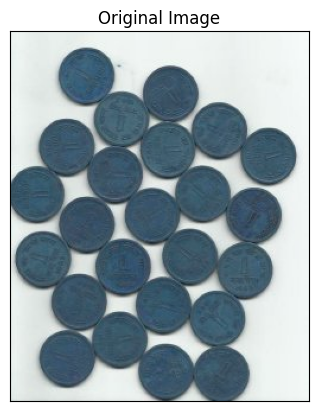

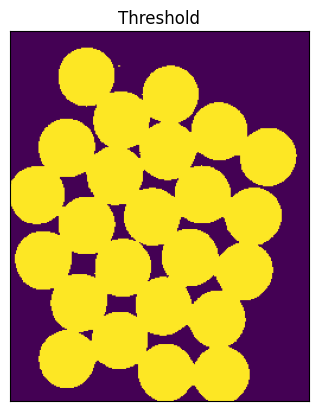

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('coins.jpg')
img_gray  =cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(img_gray,0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

plt.imshow(img), plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.show()
plt.imshow(thresh), plt.title('Threshold'), plt.xticks([]), plt.yticks([])
plt.show()

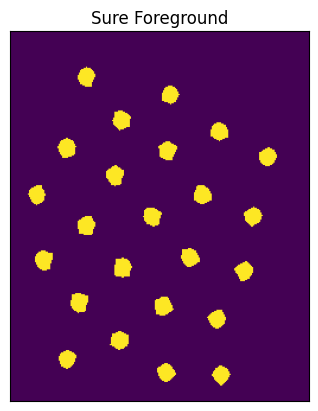

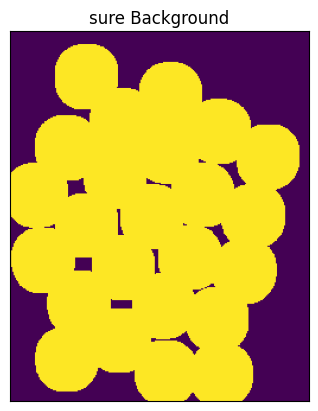

In [5]:
# noise removal
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# sure background area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# sure foreground
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255, 0)

# finding unknown region
sure_fg = np.uint8(sure_fg)
unknwon = cv2.subtract(sure_bg, sure_fg)

plt.imshow(sure_fg), plt.title('Sure Foreground'), plt.xticks([]), plt.yticks([])
plt.show()
plt.imshow(sure_bg), plt.title('sure Background'), plt.xticks([]), plt.yticks([])
plt.show()

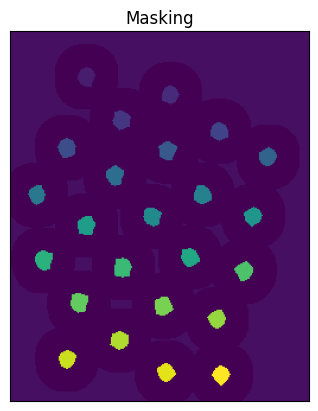

In [6]:
# now after knowing background and foreground
# we can masking two regions simultaniously to see things and segmentation effective

# marker labelling
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers+1 # background must be 1
markers[unknwon==255]=0

plt.imshow(markers), plt.title('Masking'), plt.xticks([]), plt.yticks([])
plt.show()

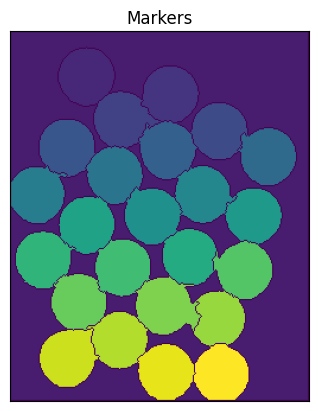

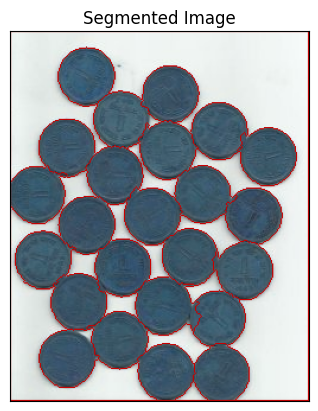

In [7]:
# now applying watershet to segment that thing
markers = cv2.watershed(img, markers)
img[markers==-1] = [200, 0, 0]

plt.imshow(markers), plt.title('Markers'), plt.xticks([]), plt.yticks([])
plt.show()
plt.imshow(img), plt.title('Segmented Image'), plt.xticks([]), plt.yticks([])
plt.show()